
# 📊 EDA de un portafolio de activos con Python
### Matplotlib · Seaborn · Pandas · yfinance

**Curso:** Lenguajes de programación  
**Tema:** Visualización y Análisis Exploratorio de Datos (EDA)  
**Caso:** análisis exploratorio de un portafolio de activos financieros

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook podrás:

- reconocer qué es una librería y para qué sirve;
- diferenciar **dato, variable, gráfico e interpretación**;
- crear gráficos básicos con **Matplotlib**;
- utilizar **Seaborn** para explorar distribuciones y relaciones;
- interpretar correctamente los gráficos;
- descargar datos históricos con **yfinance**;
- calcular rendimientos;
- explorar volatilidad, distribución y correlación;
- construir una primera lectura exploratoria de un portafolio.

> **Idea central:** un gráfico no es el resultado del análisis.  
> El gráfico es una herramienta que nos ayuda a **formular preguntas, encontrar patrones y comunicar hallazgos**.



## 🧭 Ruta de la clase

Trabajaremos de manera incremental:

**1. Datos → 2. Variables → 3. Gráfico → 4. Interpretación → 5. EDA → 6. Datos financieros reales**

| Etapa | Pregunta |
|---|---|
| Conceptos | ¿Qué estamos visualizando? |
| Matplotlib | ¿Cómo se construye un gráfico? |
| Seaborn | ¿Cómo exploramos una variable o relación? |
| EDA | ¿Qué patrones encontramos? |
| yfinance | ¿Cómo trabajamos con datos reales? |
| Portafolio | ¿Cómo se comportan conjuntamente los activos? |



# 1. Antes de graficar: pensemos como analistas

Supongamos que tenemos:

| Día | Precio |
|---:|---:|
| 1 | 100 |
| 2 | 103 |
| 3 | 101 |
| 4 | 108 |
| 5 | 112 |

Tenemos dos conceptos diferentes:

### Variable
Una característica que podemos observar o medir.  
Ejemplo: `Precio`.

### Observación
Un valor concreto de una variable.  
Ejemplo: el precio del día 4 es `108`.

### ¿Por qué graficar?

La tabla nos da los valores. El gráfico nos permite **ver la estructura de los datos**.

Por ejemplo:

- ¿el precio está aumentando?
- ¿hay caídas?
- ¿hay cambios bruscos?
- ¿existe una tendencia?

Ese proceso de preguntar, observar y encontrar patrones forma parte del **Análisis Exploratorio de Datos (EDA)**.



# 2. Las librerías que vamos a utilizar

Una **librería** es un conjunto de código reutilizable que otras personas han desarrollado para resolver problemas.

Hoy utilizaremos:

### 🐼 Pandas
Para trabajar con datos tabulares.

### 📈 Matplotlib
Para construir y personalizar visualizaciones.

### 🎨 Seaborn
Para crear visualizaciones estadísticas de forma sencilla y trabajar cómodamente con DataFrames.

### 💰 yfinance
Para obtener datos históricos de activos financieros desde Yahoo Finance.

La relación será:

```text
yfinance
   ↓
datos financieros
   ↓
Pandas
   ↓
transformaciones
   ↓
Matplotlib / Seaborn
   ↓
visualización
   ↓
interpretación
```


In [1]:
# Importamos las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline



## ¿Qué significa `import`?

Cuando escribimos:

```python
import matplotlib.pyplot as plt
```

estamos diciendo:

> "Quiero utilizar el módulo `pyplot` de la librería `matplotlib` y voy a llamarlo `plt`."

Por eso posteriormente podemos escribir:

```python
plt.plot(...)
```

El nombre `plt` es un **alias**. No es obligatorio llamarlo así, pero es una convención muy utilizada.

Lo mismo ocurre con:

```python
import seaborn as sns
import pandas as pd
import numpy as np
```



# 3. Nuestro primer gráfico: de una tabla a una visualización

Comencemos con datos muy pequeños para entender **qué hace cada instrucción**.

Tenemos el precio de un activo durante cinco días.


In [2]:
dias = [1, 2, 3, 4, 5]
precios = [100, 103, 101, 108, 112]

datos_ejemplo = pd.DataFrame({
    "Día": dias,
    "Precio": precios
})

datos_ejemplo


,Día,Precio
0,1,100
1,2,103
2,3,101
3,4,108
4,5,112



### Primer intento

Queremos representar:

- eje X → día
- eje Y → precio

La función `plot()` recibe normalmente una serie de valores para X y otra para Y.


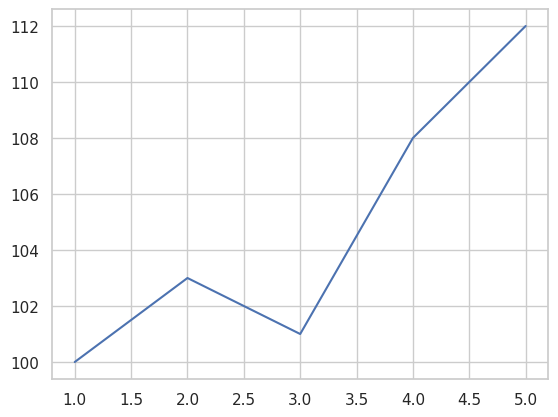

In [3]:
plt.plot(dias, precios)
plt.show()



## 🔎 ¿Qué acaba de ocurrir?

`plt.plot(x, y)`:

- toma los valores de `x`;
- toma los valores de `y`;
- coloca cada par `(x, y)` en el plano;
- conecta los puntos.

En nuestro ejemplo:

```text
(1,100)
(2,103)
(3,101)
(4,108)
(5,112)
```

### ¿Cómo lo interpretamos?

No debemos decir simplemente "el gráfico sube".

Podemos decir:

> **El precio presenta una tendencia general creciente durante el período observado, aunque existe una disminución entre los días 2 y 3.**

Esa segunda frase ya es una **interpretación**.



# 4. Hacer que el gráfico comunique mejor

Un gráfico debe permitir que otra persona entienda rápidamente:

1. **qué está viendo**;
2. **qué representan los ejes**;
3. **qué unidad se está utilizando**;
4. **qué período se está observando**.

Para eso agregamos título y etiquetas.


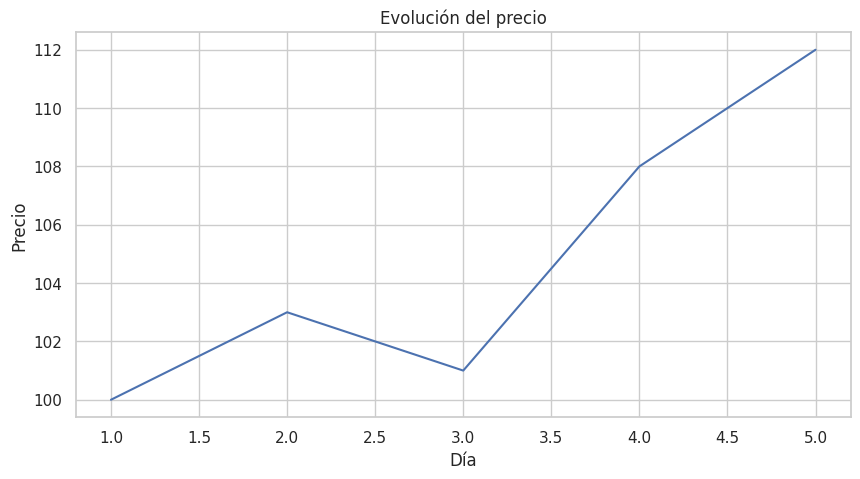

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(dias, precios)

plt.title("Evolución del precio")
plt.xlabel("Día")
plt.ylabel("Precio")

plt.show()



## 🧩 Anatomía de un gráfico

```text
                 TÍTULO
        Evolución del precio

  Y
  ↑
  │             ●
  │          ●
  │     ●
  │        ●
  │  ●
  └──────────────────────→ X
       Día
```

### Elementos principales

- **Título:** comunica qué estamos observando.
- **Eje X:** normalmente representa tiempo o una variable explicativa.
- **Eje Y:** representa la variable que queremos analizar.
- **Línea/puntos:** representan los datos.
- **Leyenda:** identifica las series cuando tenemos varias.



# 5. La interfaz orientada a objetos de Matplotlib

Hasta ahora utilizamos `plt` directamente.

Existe otra forma muy importante:

```python
fig, ax = plt.subplots()
```

Aquí aparecen dos objetos:

### `fig`
Es la **figura completa**, el espacio donde estará nuestro gráfico.

### `ax`
Es el **área de ejes** donde realmente dibujamos.

Una forma sencilla de imaginarlo:

```text
Figure
┌─────────────────────────────┐
│                             │
│       Axes                  │
│     ┌───────────────┐       │
│     │   gráfico     │       │
│     │               │       │
│     └───────────────┘       │
│                             │
└─────────────────────────────┘
```


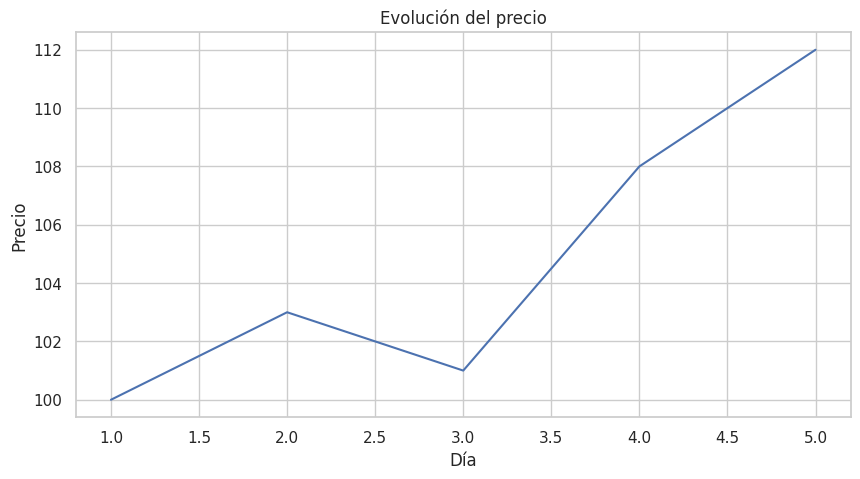

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dias, precios)

ax.set_title("Evolución del precio")
ax.set_xlabel("Día")
ax.set_ylabel("Precio")

plt.show()



### ¿Por qué aprender esta forma?

Cuando los gráficos se vuelven más complejos, trabajar con `fig` y `ax` nos da mayor control.

Por ejemplo, podemos tener varios gráficos dentro de una misma figura y controlar cada eje por separado.

**Regla práctica para la clase:**

- `plt.plot()` → muy útil para comenzar.
- `fig, ax = plt.subplots()` → recomendable cuando queremos construir gráficos de forma más estructurada.



# 6. Gráficos de varias series

Ahora supongamos que tenemos tres activos.


In [6]:
precios_portafolio = pd.DataFrame({
    "AAPL": [100, 103, 101, 108, 112],
    "MSFT": [100, 102, 104, 106, 109],
    "NVDA": [100, 98, 105, 110, 120]
}, index=[1, 2, 3, 4, 5])

precios_portafolio


,AAPL,MSFT,NVDA
1,100,100,100
2,103,102,98
3,101,104,105
4,108,106,110
5,112,109,120



Si graficamos los precios directamente, podemos comparar las series.

Pero aparece un problema importante:

> ¿Cómo comparamos activos que originalmente tienen precios diferentes?

Por ahora nuestros datos comienzan todos en 100. Esto es intencional: queremos concentrarnos en la **forma de la serie** antes de introducir los rendimientos.


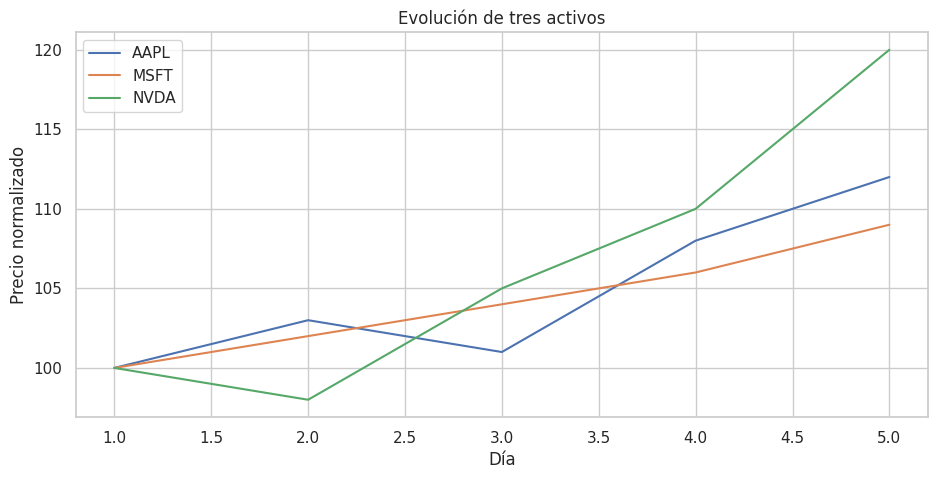

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(precios_portafolio.index, precios_portafolio["AAPL"], label="AAPL")
ax.plot(precios_portafolio.index, precios_portafolio["MSFT"], label="MSFT")
ax.plot(precios_portafolio.index, precios_portafolio["NVDA"], label="NVDA")

ax.set_title("Evolución de tres activos")
ax.set_xlabel("Día")
ax.set_ylabel("Precio normalizado")
ax.legend()

plt.show()



## 🧠 Interpretación

Observe primero, **después interprete**.

Preguntas:

1. ¿Cuál serie termina más arriba?
2. ¿Cuál presenta más cambios?
3. ¿Hay momentos en los que dos activos se mueven en direcciones diferentes?
4. ¿Podemos concluir cuál es "mejor" solamente con este gráfico?

La última pregunta es importante:

> **No.** Un gráfico puede mostrar comportamiento histórico, pero no convierte automáticamente ese comportamiento en una recomendación de inversión.



# 7. Seaborn: visualización orientada al análisis estadístico

Seaborn está construido sobre Matplotlib y facilita muchos gráficos estadísticos.

Una ventaja importante es que puede trabajar directamente con estructuras de Pandas.

Vamos a utilizar primero un **histograma**.


In [8]:
# Generamos una muestra sencilla de rendimientos

np.random.seed(42)

rendimientos_ejemplo = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=500
)

rendimientos_ejemplo[:10]


array([ 0.01093428, -0.00176529,  0.01395377,  0.0314606 , -0.00368307,
       -0.00368274,  0.03258426,  0.01634869, -0.00838949,  0.0118512 ])


## ¿Qué pregunta responde un histograma?

Un histograma permite observar cómo se distribuyen los valores.

Por ejemplo:

> ¿En qué rango se concentran los rendimientos?


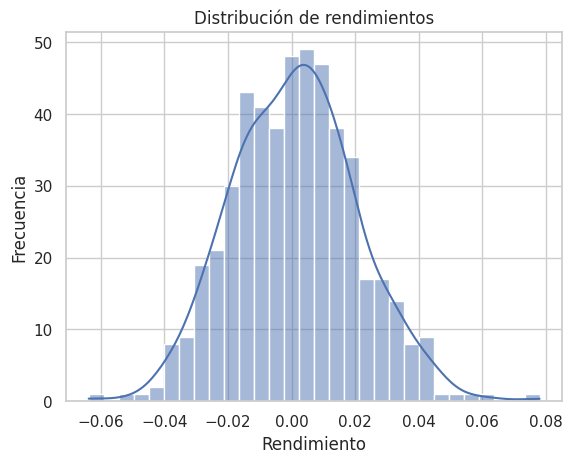

In [9]:
sns.histplot(
    rendimientos_ejemplo,
    bins=30,
    kde=True
)

plt.title("Distribución de rendimientos")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.show()



## 🔎 ¿Cómo interpretar un histograma?

Observemos:

### Centro
¿Dónde se concentran la mayoría de los valores?

### Dispersión
¿Qué tan extendidos están los datos?

### Colas
¿Hay valores alejados del centro?

### Forma
¿La distribución parece simétrica o presenta algún sesgo?

**Importante:** la forma del histograma depende de decisiones como el número de `bins`. No debemos interpretar cada detalle visual como una propiedad exacta de los datos.



# 8. Boxplot: detectar dispersión y valores extremos

Un boxplot resume visualmente una distribución.

Conceptualmente muestra:

- mediana;
- cuartiles;
- rango intercuartílico;
- posibles valores extremos.



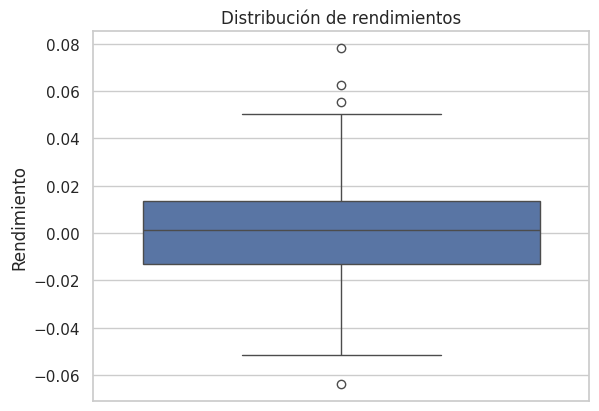

In [10]:
sns.boxplot(y=rendimientos_ejemplo)

plt.title("Distribución de rendimientos")
plt.ylabel("Rendimiento")

plt.show()



### Preguntas para interpretar

- ¿Dónde está la mediana?
- ¿Qué tan grande es la caja?
- ¿Qué tan largos son los bigotes?
- ¿Aparecen observaciones alejadas?

El objetivo no es memorizar la forma del dibujo.

El objetivo es poder decir:

> "La distribución presenta mayor/menor dispersión..."

y justificarlo a partir del gráfico.



# 9. Scatter plot: estudiar relaciones

Ahora queremos estudiar dos variables.

Por ejemplo:

> ¿Los cambios diarios de AAPL y MSFT tienden a ocurrir en la misma dirección?

Para eso usamos un **scatter plot**.

Cada punto representa una observación.


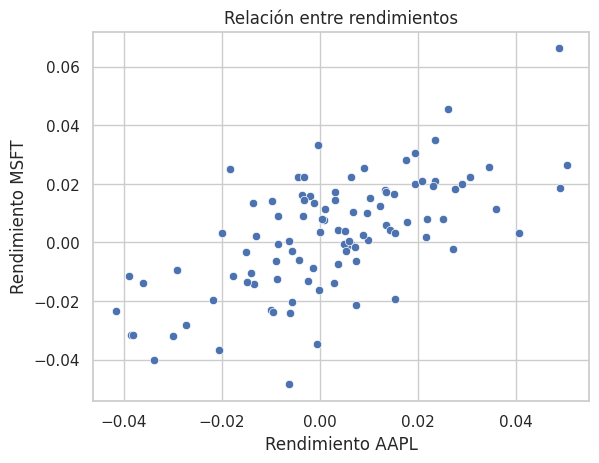

In [11]:
np.random.seed(10)

aapl = np.random.normal(0.001, 0.02, 100)
msft = aapl * 0.6 + np.random.normal(0, 0.015, 100)

sns.scatterplot(x=aapl, y=msft)

plt.title("Relación entre rendimientos")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



## Interpretación

Buscamos patrones:

- nube ascendente → posible relación positiva;
- nube descendente → posible relación negativa;
- nube sin orientación clara → relación lineal débil o inexistente.

Pero recuerda:

> **Correlación no significa causalidad.**

Dos variables pueden moverse juntas sin que una sea la causa de la otra.



# 10. Correlación y mapa de calor

La correlación permite cuantificar la relación lineal entre dos variables.

En Python:

```python
df.corr()
```

produce una matriz de correlaciones.

Valores cercanos a:

- `1` → relación lineal positiva fuerte;
- `0` → relación lineal débil;
- `-1` → relación lineal negativa fuerte.

Veámoslo visualmente.


In [12]:
datos_rendimientos = pd.DataFrame({
    "AAPL": aapl,
    "MSFT": msft,
    "NVDA": aapl * 0.3 + np.random.normal(0, 0.025, 100)
})

correlacion = datos_rendimientos.corr()

correlacion


,AAPL,MSFT,NVDA
AAPL,1.000000,0.648544,0.207646
MSFT,0.648544,1.000000,0.205384
NVDA,0.207646,0.205384,1.000000


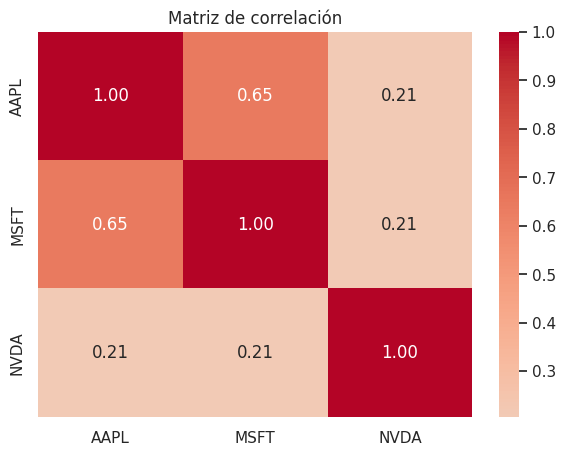

In [13]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()



## 🧠 Interpretar el heatmap

La matriz permite responder rápidamente:

> ¿Qué activos tienen comportamientos más similares?

Pero debemos tener cuidado:

- la correlación mide principalmente **relación lineal**;
- una correlación histórica no garantiza que se mantenga igual;
- correlación no significa causalidad;
- el período elegido afecta el resultado.

Para un análisis financiero serio también debemos considerar el período, frecuencia, calidad de datos y contexto del mercado.



# 11. Ahora sí: datos reales con yfinance 💰

Hasta este momento utilizamos datos pequeños o simulados para entender la visualización.

Ahora vamos a trabajar con datos reales.

Instalación, si el entorno todavía no tiene la librería:

```bash
pip install yfinance
```

Importamos:


In [14]:
import yfinance as yf



## ¿Qué activos vamos a estudiar?

Usaremos como ejemplo:

- `AAPL` — Apple
- `MSFT` — Microsoft
- `GOOGL` — Alphabet
- `AMZN` — Amazon
- `NVDA` — NVIDIA

Los símbolos son **tickers**, identificadores utilizados para localizar activos en los mercados.

> Los datos obtenidos mediante servicios externos pueden cambiar con el tiempo. Para una clase de EDA esto es útil: cada estudiante puede obtener una fotografía diferente del período consultado.


In [15]:
activos = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  183.404037  149.929993  136.867584  363.117920  48.028790   
2024-01-03  182.030746  148.470001  137.610519  362.853607  47.431522   
2024-01-04  179.718933  144.570007  135.104385  360.249176  47.859283   
2024-01-05  178.997711  145.240005  134.450607  360.063141  48.955105   
2024-01-08  183.324966  149.100006  137.531281  366.858093  52.101990   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA  ...   
Date                                                                   ...   
2024-01-02  186.170316  152.380005  138.135518  368.042780  49.152531  ...   
2024-01-03  183.641118  151.050003  138.313834  365.458011  48.044743  ...   
2024-01-04  180.884713  147.380005  137.848280  365.301323  48.359832  ...   
2024-01-05  180.558682  146.589996  135.867136  364.283049  49.403805  ...   
2024-01-08  183.364493  149.399994  137.699676  367.357443  52.123929  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  184.895845  151.539993  137.244007  366.045412  49.101680   
2024-01-03  182.001109  149.199997  135.956263  361.296845  47.347766   
2024-01-04  179.956033  145.589996  137.115249  362.922123  47.628948   
2024-01-05  179.797968  144.690002  135.460997  361.257641  48.321942   
2024-01-08  179.896761  146.740005  135.005314  361.580743  49.368914   

Price         Volume                                           
Ticker          AAPL      AMZN     GOOGL      MSFT       NVDA  
Date                                                           
2024-01-02  82488700  47339400  23711200  25258600  411254000  
2024-01-03  58414500  49425500  24212100  23083500  320896000  
2024-01-04  71983600  56039800  27137700  20901500  306535000  
2024-01-05  62379700  45153100  22513900  21004600  415039000  
2024-01-08  59144500  46757100  21404000  23134000  642510000  

[5 rows x 25 columns]


# 12. Antes de graficar: conozcamos nuestros datos

Una regla fundamental de EDA:

> **No empieces a graficar sin conocer primero el DataFrame.**

Preguntas básicas:

- ¿cuántas filas tenemos?
- ¿cuántas columnas?
- ¿qué tipo de datos?
- ¿hay valores faltantes?
- ¿qué período cubren?


In [16]:
print("Dimensiones:", precios.shape)

precios.info()


Dimensiones: (502, 25)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    502 non-null    float64
 1   (Close, AMZN)    502 non-null    float64
 2   (Close, GOOGL)   502 non-null    float64
 3   (Close, MSFT)    502 non-null    float64
 4   (Close, NVDA)    502 non-null    float64
 5   (High, AAPL)     502 non-null    float64
 6   (High, AMZN)     502 non-null    float64
 7   (High, GOOGL)    502 non-null    float64
 8   (High, MSFT)     502 non-null    float64
 9   (High, NVDA)     502 non-null    float64
 10  (Low, AAPL)      502 non-null    float64
 11  (Low, AMZN)      502 non-null    float64
 12  (Low, GOOGL)     502 non-null    float64
 13  (Low, MSFT)      502 non-null    float64
 14  (Low, NVDA)      502 non-null    float64
 15  (Open, AAPL)     502 non-null    float64
 16  (Open, AMZN)     502

In [17]:
precios.describe()


Price        Close                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    218.163909  201.084920  186.196406  436.391722  130.434590   
std      29.061803   23.894482   44.695116   44.590889   36.478682   
min     163.220642  144.570007  130.161407  350.446106   47.431522   
25%     197.301426  182.045002  160.382690  404.577171  107.877958   
50%     220.355461  199.269997  171.818100  420.492218  129.622070   
75%     234.987225  223.067505  193.867229  475.532745  157.790573   
max     285.413116  254.000000  322.601013  537.646362  206.545166   

Price         High                                                  ...  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA  ...   
count   502.000000  502.000000  502.000000  502.000000  502.000000  ...   
mean    220.247259  203.257610  188.240374  439.904429  132.605679  ...   
std      29.157375   24.065589   45.248698   44.664830   36.763190  ...   
min     164.605538  146.589996  131.984099  360.251011   48.044743  ...   
25%     199.331459  184.752499  162.219149  407.837381  110.606056  ...   
50%     222.591318  200.525002  173.761189  423.625078  132.120727  ...   
75%     237.294614  225.872498  195.231444  480.116550  158.770658  ...   
max     287.836529  258.600006  327.977016  550.013050  211.682867  ...   

Price         Open                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    217.941191  201.160956  186.098552  436.394020  130.481371   
std      29.027179   24.115082   44.736023   44.931146   36.636461   
min     163.566871  144.690002  130.636917  346.808771   47.347766   
25%     196.633052  182.320004  160.184679  404.190604  107.114857   
50%     219.779628  199.305000  172.185861  420.292252  129.651070   
75%     234.190545  223.520004  192.999159  476.422511  157.940189   
max     285.423116  255.360001  325.363817  549.795172  207.582657   

Price         Volume                                                          
Ticker          AAPL          AMZN         GOOGL          MSFT          NVDA  
count   5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  
mean    5.564712e+07  4.270025e+07  3.183945e+07  2.138683e+07  2.992817e+08  
std     2.732569e+07  1.823593e+07  1.448971e+07  8.027734e+06  1.537611e+08  
min     1.791060e+07  1.142050e+07  1.009740e+07  5.855900e+06  6.552850e+07  
25%     4.132715e+07  3.153310e+07  2.236578e+07  1.632950e+07  1.841153e+08  
50%     4.890840e+07  3.871275e+07  2.853320e+07  1.958820e+07  2.505988e+08  
75%     6.041002e+07  4.680382e+07  3.582398e+07  2.359505e+07  3.779842e+08  
max     3.186799e+08  1.663408e+08  1.274901e+08  7.083610e+07  1.142269e+09  

[8 rows x 25 columns]

In [18]:
precios.isna().sum()


Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64


### 🧪 Mini-reto

Antes de continuar, responde:

1. ¿Cuántas observaciones tenemos?
2. ¿Cuál es la primera fecha?
3. ¿Cuál es la última fecha?
4. ¿Existen valores faltantes?
5. ¿Qué representa cada nivel de columnas?

**No continúes hasta intentar responderlas.**



# 13. Seleccionar el precio de cierre

`yfinance` devuelve varias variables para cada activo, entre ellas:

- Open
- High
- Low
- Close
- Volume

Para nuestro primer análisis utilizaremos **Close**, el precio de cierre ajustado según la configuración utilizada.



In [19]:
cierre = precios["Close"]

cierre.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,183.404037,149.929993,136.867584,363.117920,48.028790
2024-01-03,182.030746,148.470001,137.610519,362.853607,47.431522
2024-01-04,179.718933,144.570007,135.104385,360.249176,47.859283
2024-01-05,178.997711,145.240005,134.450607,360.063141,48.955105
2024-01-08,183.324966,149.100006,137.531281,366.858093,52.101990



## Visualicemos los precios

Primera pregunta del EDA:

> **¿Cómo evolucionaron los precios de los activos durante el período?**


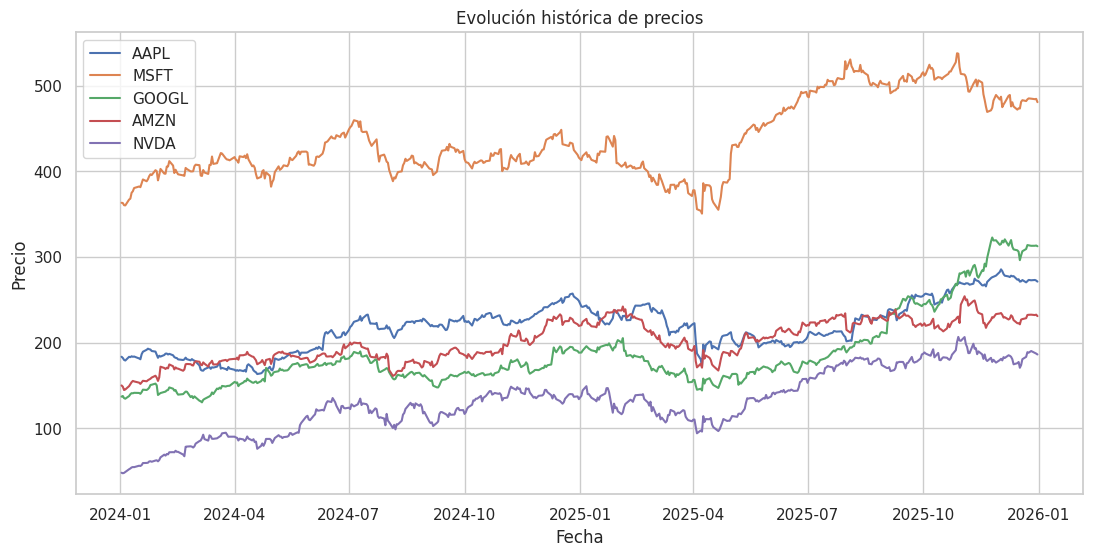

In [20]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()



## ⚠️ Una dificultad de comparar precios

AAPL puede tener un precio nominal diferente de NVDA, MSFT, etc.

Eso hace que comparar las alturas directamente pueda ser engañoso.

Una solución sencilla para estudiar **crecimiento relativo** es normalizar las series.

Por ejemplo:

```python
precio_normalizado = precio / precio_inicial * 100
```

Así todos comienzan en 100.


In [21]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2024-01-03,99.251221,99.026218,100.542813,99.927210,98.756439
2024-01-04,97.990718,96.425008,98.711748,99.209969,99.647074
2024-01-05,97.597476,96.871882,98.234076,99.158736,101.928667
2024-01-08,99.956887,99.446417,100.484919,101.030016,108.480747


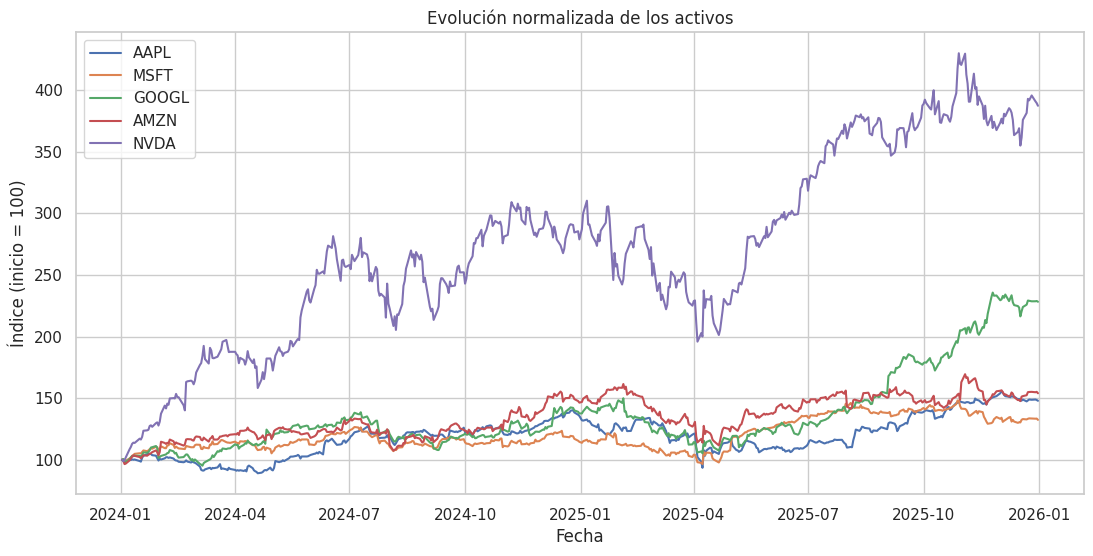

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()



### ¿Qué pregunta responde este gráfico?

No responde:

> "¿Cuál tiene el precio más alto?"

Responde mejor:

> **"¿Cómo cambió cada activo respecto a su propio punto inicial?"**

Esta distinción es fundamental en análisis de datos financieros.



# 14. Rendimientos: transformar los precios

En análisis financiero suele ser útil estudiar **rendimientos** en lugar de precios.

Un rendimiento porcentual simple entre dos períodos puede calcularse como:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

En Pandas podemos obtenerlo con:

```python
pct_change()
```


In [23]:
rendimientos = cierre.pct_change()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,NaN,NaN,NaN,NaN,NaN
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009018
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281



El primer registro normalmente será `NaN` porque no tenemos un precio anterior con el cual compararlo.

Eliminemos esos valores para las visualizaciones que lo necesiten.


In [24]:
rendimientos = rendimientos.dropna()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009018
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281
2024-01-09,-0.002263,0.015225,0.015198,0.002936,0.016975



# 15. EDA de los rendimientos

### Pregunta 1
**¿Cómo se comportan los rendimientos a través del tiempo?**


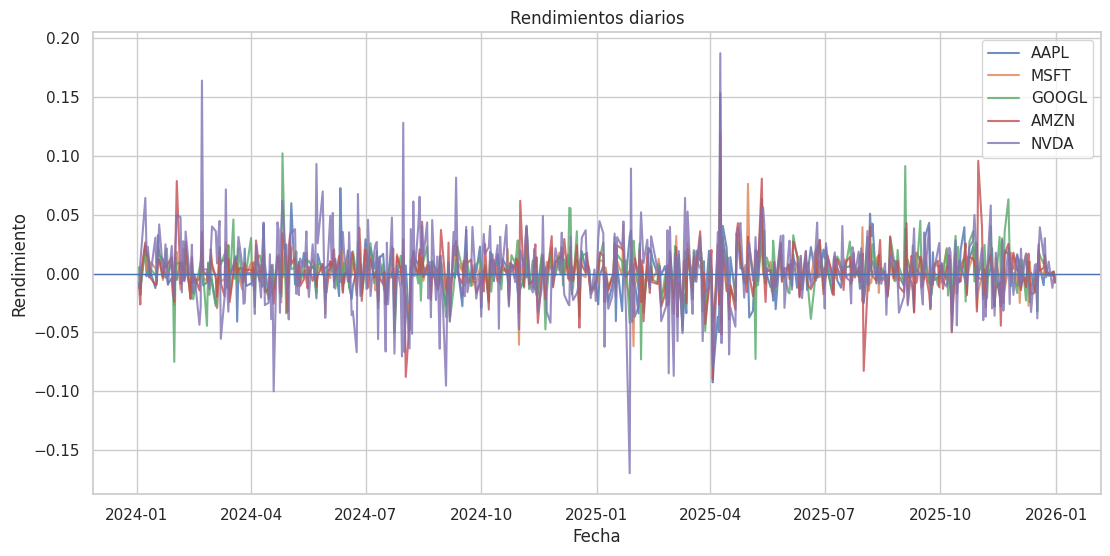

In [25]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()



### Interpretación

La línea horizontal en cero nos ayuda a distinguir:

- valores positivos → rendimiento positivo;
- valores negativos → rendimiento negativo.

Busca:

- períodos de mayor variabilidad;
- movimientos extremos;
- momentos donde varios activos caen simultáneamente;
- diferencias entre activos.

**No confundas variabilidad con rendimiento.**

Un activo puede tener grandes movimientos hacia arriba y hacia abajo y terminar cerca del punto inicial.



# 16. Distribución de rendimientos

Ahora usamos Seaborn para estudiar una variable desde otro ángulo.

Pregunta:

> **¿Cómo se distribuyen los rendimientos diarios de cada activo?**


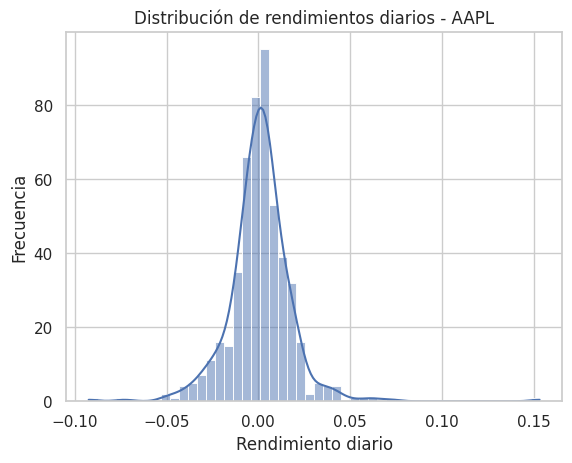

In [26]:
sns.histplot(
    data=rendimientos,
    x="AAPL",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - AAPL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()



## 🧪 Cambia el activo

Modifica `"AAPL"` por:

```python
"MSFT"
"GOOGL"
"AMZN"
"NVDA"
```

### Pregunta

¿Qué diferencias observas entre las distribuciones?

No busques solamente cuál "se ve mejor".

Describe:

- centro;
- dispersión;
- valores extremos;
- forma de la distribución.



# 17. Comparar la dispersión con un boxplot

Ahora podemos comparar todos los activos simultáneamente.


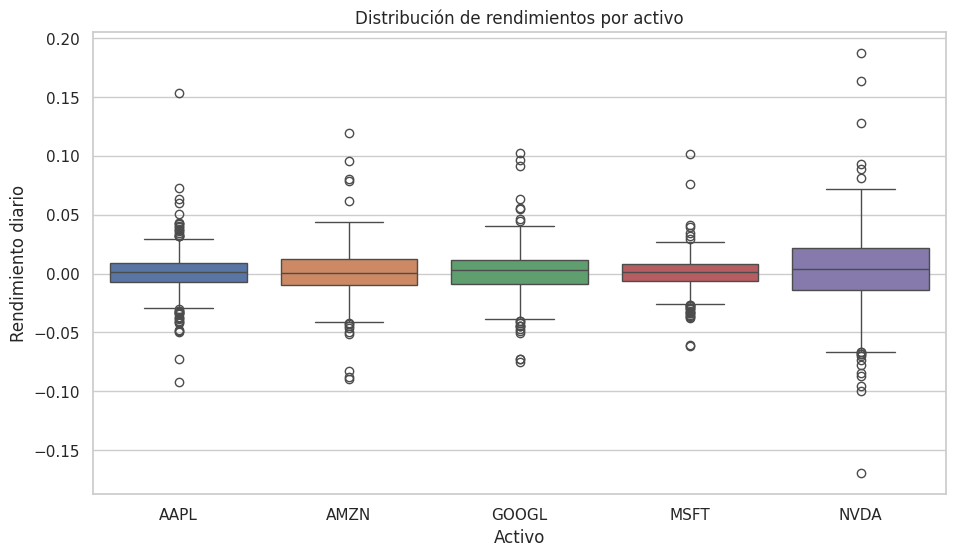

In [27]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()



### Preguntas de análisis

1. ¿Qué activos muestran mayor dispersión?
2. ¿Qué activos presentan más observaciones alejadas?
3. ¿Las medianas están cerca de cero?
4. ¿Qué información perderíamos si solo observáramos el precio?

Aquí aparece una idea importante:

> **Una buena visualización permite comparar una propiedad concreta de los datos.**



# 18. Matriz de correlación del portafolio

Ahora llegamos a una de las visualizaciones más importantes para nuestro caso.

Pregunta:

> **¿Cómo se relacionan los rendimientos de los activos entre sí?**


In [28]:
correlacion = rendimientos.corr()

correlacion


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.484033,0.442986,0.479061,0.350518
AMZN,0.484033,1.000000,0.540440,0.625640,0.505377
GOOGL,0.442986,0.540440,1.000000,0.485902,0.398910
MSFT,0.479061,0.625640,0.485902,1.000000,0.549245
NVDA,0.350518,0.505377,0.398910,0.549245,1.000000


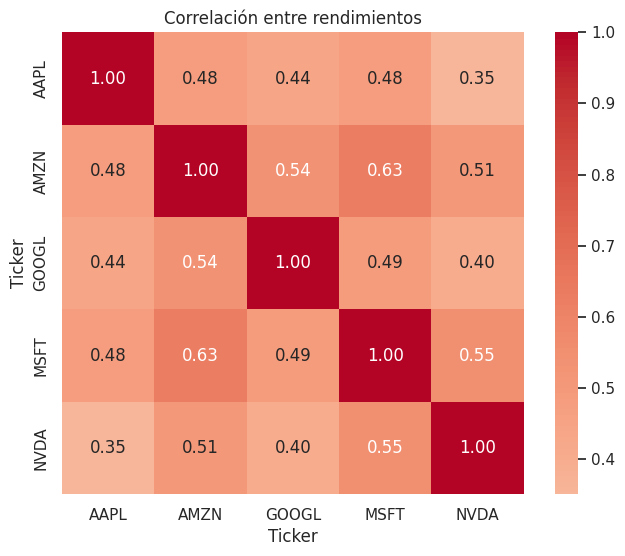

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()



## 🧠 ¿Cómo leer la matriz?

Supongamos que encontramos:

```text
             AAPL    MSFT
AAPL          1.00   0.70
MSFT          0.70   1.00
```

La diagonal es 1 porque cada activo está perfectamente correlacionado consigo mismo.

Un valor de `0.70` indica una relación lineal positiva relativamente alta en el período analizado.

### Pregunta de portafolio

Si dos activos presentan una correlación elevada:

> ¿Qué implica esto para la diversificación?

Una posible interpretación es que **pueden proporcionar menos diversificación entre sí que dos activos con una correlación menor**, aunque la diversificación real depende de muchos otros factores.

No debemos convertir la correlación, por sí sola, en una recomendación de inversión.



# 19. Scatter plot: profundicemos en una pareja

Seleccionemos dos activos:

```python
AAPL
MSFT
```

Cada punto representa un día.

- X → rendimiento de AAPL
- Y → rendimiento de MSFT



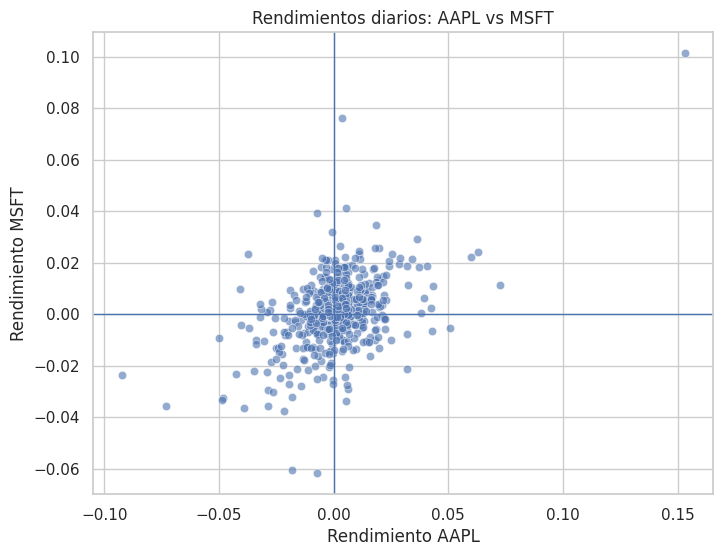

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="AAPL",
    y="MSFT",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: AAPL vs MSFT")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



### Preguntas para interpretar

Observa la nube de puntos:

1. ¿Existe una orientación ascendente?
2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
3. ¿MSFT suele tener el mismo signo?
4. ¿Hay valores extremos?
5. ¿La relación parece perfectamente lineal?

El scatter plot y la matriz de correlación están contando historias relacionadas, pero desde perspectivas diferentes:

**Scatter → vemos las observaciones individuales.**  
**Correlación → resumimos numéricamente la relación lineal.**



# 20. Estadísticas descriptivas del portafolio

La visualización debe complementarse con medidas numéricas.



In [31]:
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
AAPL,0.000933,0.001187,0.017571,-0.092456,0.153289
AMZN,0.001056,0.000648,0.019781,-0.089791,0.119770
GOOGL,0.001829,0.002923,0.019062,-0.075004,0.102244
MSFT,0.000657,0.001111,0.013975,-0.061809,0.101337
NVDA,0.003222,0.003503,0.032181,-0.169682,0.187227



## ¿Qué estamos viendo?

### Media
Promedio de los rendimientos.

### Mediana
Valor central de la distribución.

### Desviación estándar
Medida de dispersión utilizada frecuentemente como una aproximación de la volatilidad histórica.

### Mínimo / máximo
Permiten observar los extremos registrados en el período.

**Importante:** estas estadísticas describen el período analizado. No garantizan que el futuro se comporte igual.



# 21. Mini-proyecto: EDA completo

Ahora debes construir tu propio análisis.

## Objetivo

Selecciona entre **3 y 5 activos** y realiza un EDA.

### Paso 1 — Datos

Descarga los datos históricos.

### Paso 2 — Calidad

Revisa:

- dimensiones;
- tipos;
- valores faltantes;
- período.

### Paso 3 — Precios

Construye un gráfico de evolución de precios.

### Paso 4 — Normalización

Construye un gráfico con todas las series comenzando en 100.

### Paso 5 — Rendimientos

Calcula los rendimientos diarios.

### Paso 6 — Distribución

Construye un histograma para uno de los activos.

### Paso 7 — Comparación

Construye un boxplot de los rendimientos.

### Paso 8 — Relación

Construye una matriz de correlación.

### Paso 9 — Relación entre dos activos

Construye un scatter plot.

### Paso 10 — Conclusiones

Escribe **3 hallazgos**.

Cada hallazgo debe tener esta estructura:

> **Gráfico:** ¿qué gráfico utilizaste?  
> **Observación:** ¿qué ves?  
> **Interpretación:** ¿qué significa esa observación para el análisis?


---
## 🧩 Mi mini-proyecto

Activos seleccionados (4, dentro del rango de 3 a 5 que pide el enunciado): **NFLX, V, TSLA y JPM**, los de mi portafolio asignado. Uso el mismo período del ejemplo de clase (2024-01-01 a 2026-01-01) para poder comparar. Las variables de esta sección empiezan por `mi_` para no pisar las del análisis de ejemplo.

### Paso 1 — Datos

In [32]:
from itertools import combinations
from IPython.display import display, Markdown

mis_activos = ["NFLX", "V", "TSLA", "JPM"]

mi_precios = yf.download(
    mis_activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

mi_precios.head()

[*********************100%***********************]  4 of 4 completed


Price            Close                                           High  \
Ticker             JPM       NFLX        TSLA           V         JPM   
Date                                                                    
2024-01-02  162.278290  46.849998  248.419998  253.571777  162.363160   
2024-01-03  161.571014  47.026001  238.449997  252.700027  162.240565   
2024-01-04  162.643188  47.466999  237.929993  254.296646  164.483969   
2024-01-05  163.459244  47.405998  237.490005  254.375015  164.512473   
2024-01-08  163.222031  48.502998  240.449997  257.166718  163.544638   

Price                                                 Low             \
Ticker           NFLX        TSLA           V         JPM       NFLX   
Date                                                                   
2024-01-02  48.465000  251.250000  254.766809  159.288855  46.186001   
2024-01-03  47.505001  245.679993  253.561992  160.665690  46.577000   
2024-01-04  48.074001  242.699997  255.697402  161.817675  46.653000   
2024-01-05  47.955002  240.119995  256.108779  162.700157  47.180000   
2024-01-08  48.523998  241.250000  257.245067  160.821429  47.365002   

Price                                     Open                         \
Ticker            TSLA           V         JPM       NFLX        TSLA   
Date                                                                    
2024-01-02  244.410004  252.396355  159.458596  48.319000  250.080002   
2024-01-03  236.320007  251.602925  162.070824  46.731998  244.979996   
2024-01-04  237.729996  252.719612  161.912566  47.298000  239.250000   
2024-01-05  234.899994  253.454252  162.700157  47.650002  236.860001   
2024-01-08  235.300003  254.629730  163.222031  47.389000  236.139999   

Price                     Volume                                
Ticker               V       JPM      NFLX       TSLA        V  
Date                                                            
2024-01-02  254.296622   9977400  50494000  104654200  5471000  
2024-01-03  253.258339   9852300  34437000  121082600  4148300  
2024-01-04  252.788186  11972500  36365000  102629300  3843000  
2024-01-05  255.442703  10066000  26313000   92488900  3748400  
2024-01-08  255.599458  11229900  36758000   85166600  4659000

### Paso 2 — Calidad de los datos

In [33]:
mi_cierre = mi_precios["Close"][mis_activos]   # precio de cierre ajustado, en el orden asignado

print("Dimensiones:", mi_precios.shape)
print("Primera fecha:", mi_precios.index.min().date())
print("Última fecha: ", mi_precios.index.max().date())
print("Observaciones (días de negociación):", len(mi_precios))
print("Niveles de columnas:", list(mi_precios.columns.names))
print("Tipos de dato:", list(mi_precios.columns.get_level_values(0).unique()))

print("\nValores faltantes en el precio de cierre, por activo:")
print(mi_cierre.isna().sum())
print("Valores faltantes en toda la tabla:", int(mi_precios.isna().sum().sum()))

print()
mi_precios.info()

Dimensiones: (502, 20)
Primera fecha: 2024-01-02
Última fecha:  2025-12-31
Observaciones (días de negociación): 502
Niveles de columnas: ['Price', 'Ticker']
Tipos de dato: ['Close', 'High', 'Low', 'Open', 'Volume']

Valores faltantes en el precio de cierre, por activo:
Ticker
NFLX    0
V       0
TSLA    0
JPM     0
dtype: int64
Valores faltantes en toda la tabla: 0

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, JPM)    502 non-null    float64
 1   (Close, NFLX)   502 non-null    float64
 2   (Close, TSLA)   502 non-null    float64
 3   (Close, V)      502 non-null    float64
 4   (High, JPM)     502 non-null    float64
 5   (High, NFLX)    502 non-null    float64
 6   (High, TSLA)    502 non-null    float64
 7   (High, V)       502 non-null    float64
 8   (Low, JPM)      502 non-null    float64
 9   (Low, N

**Cómo leerlo:** cada fila es un día de negociación; las columnas tienen dos niveles: el **tipo de dato** (Close, High, Low, Open, Volume) y el **ticker**. Si los faltantes son 0, la tabla está completa y se puede calcular sin limpiar nada.

### Paso 3 — Evolución de precios

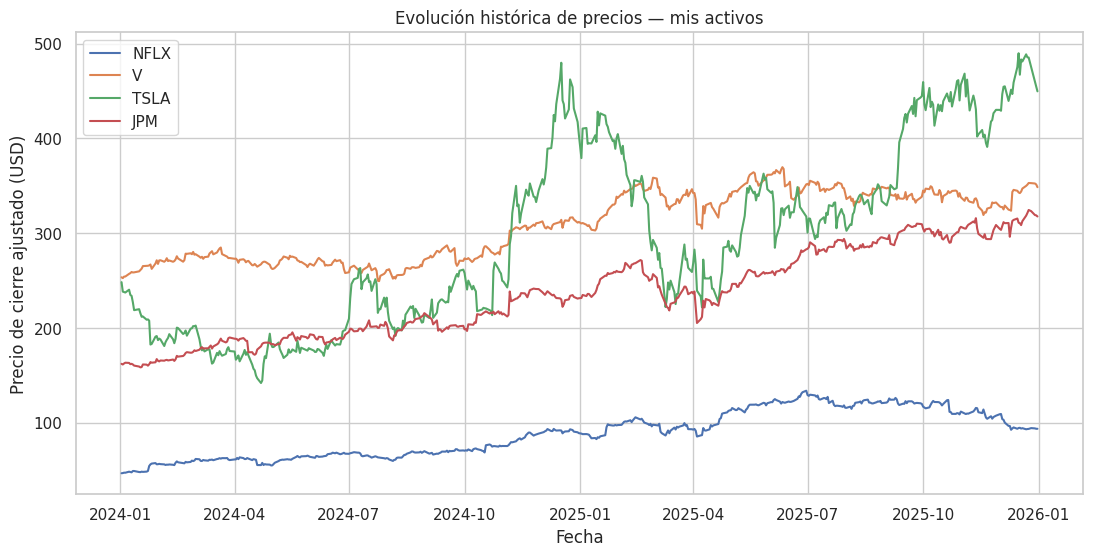

In [34]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in mis_activos:
    ax.plot(mi_cierre.index, mi_cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios — mis activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre ajustado (USD)")
ax.legend()

plt.show()

### Paso 4 — Normalización (inicio = 100)

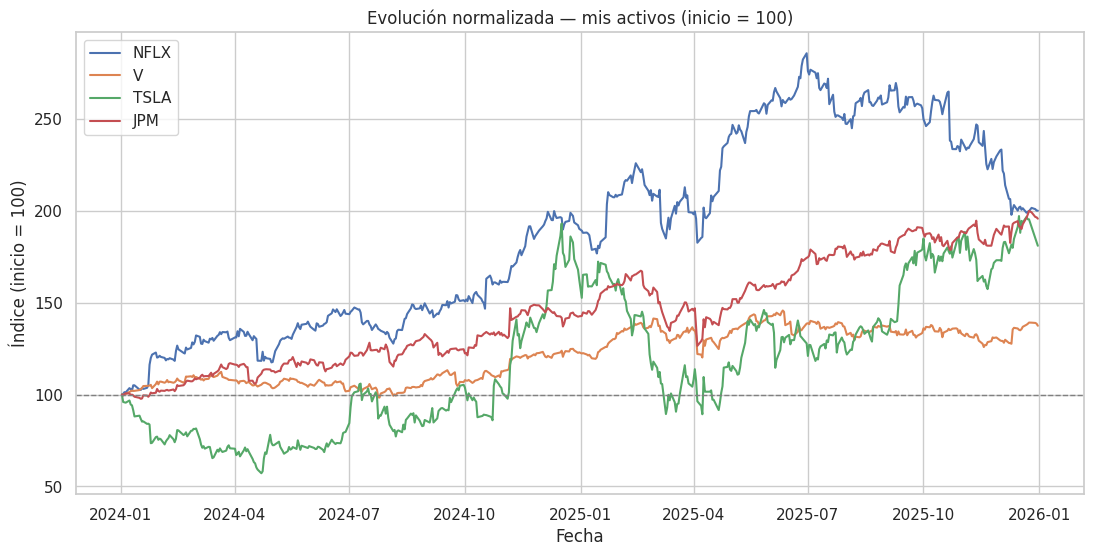

Variación acumulada del período (%), de mayor a menor:
Ticker
NFLX    100.1
JPM      95.8
TSLA     81.0
V        37.5
Name: 2025-12-31 00:00:00, dtype: float64


In [35]:
mi_normalizado = mi_cierre / mi_cierre.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 6))

for activo in mis_activos:
    ax.plot(mi_normalizado.index, mi_normalizado[activo], label=activo)

ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title("Evolución normalizada — mis activos (inicio = 100)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()

print("Variación acumulada del período (%), de mayor a menor:")
print((mi_normalizado.iloc[-1] - 100).sort_values(ascending=False).round(1))

### Paso 5 — Rendimientos diarios

Ticker,NFLX,V,TSLA,JPM
Date,,,,
2024-01-03,0.003757,-0.003438,-0.040134,-0.004358
2024-01-04,0.009378,0.006318,-0.002181,0.006636
2024-01-05,-0.001285,0.000308,-0.001849,0.005017
2024-01-08,0.023141,0.010975,0.012464,-0.001451
2024-01-09,-0.006061,0.003009,-0.022832,-0.007906


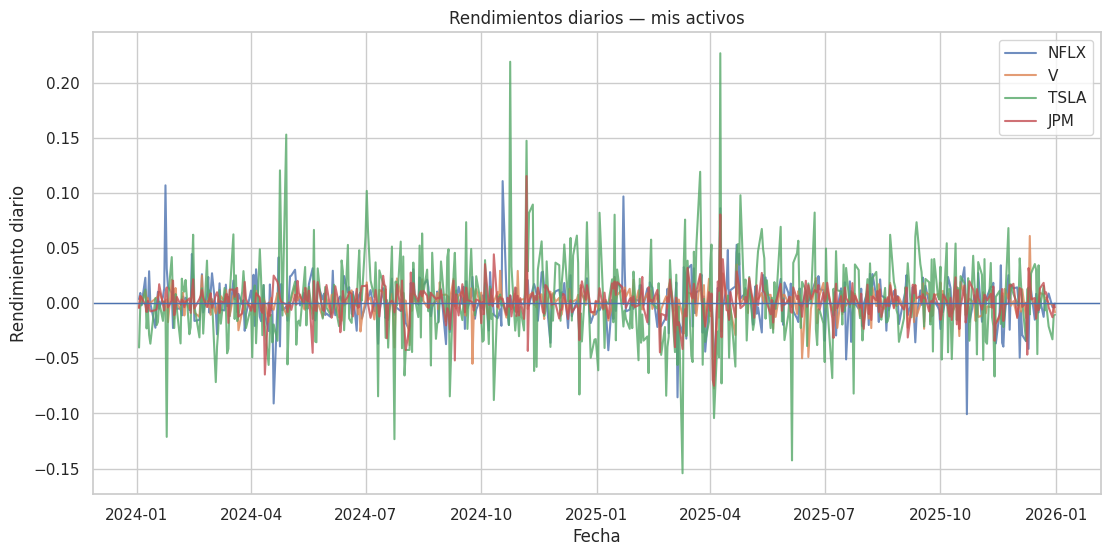

In [36]:
mi_rend = mi_cierre.pct_change().dropna()

display(mi_rend.head())

fig, ax = plt.subplots(figsize=(13, 6))

for activo in mis_activos:
    ax.plot(mi_rend.index, mi_rend[activo], label=activo, alpha=0.8)

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios — mis activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento diario")
ax.legend()

plt.show()

### Paso 6 — Distribución de un activo

Para el histograma elijo el activo con **mayor dispersión** de rendimientos, que es donde la forma de la distribución y las colas se ven mejor.

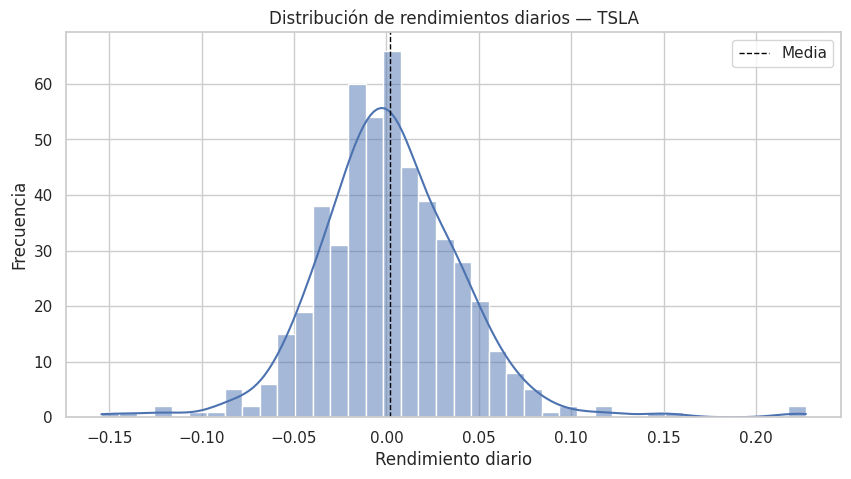

In [37]:
activo_hist = mi_rend.std().idxmax()   # el activo con mayor desviación estándar

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=mi_rend, x=activo_hist, bins=40, kde=True, ax=ax)
ax.axvline(mi_rend[activo_hist].mean(), linestyle="--", linewidth=1, color="black", label="Media")

ax.set_title(f"Distribución de rendimientos diarios — {activo_hist}")
ax.set_xlabel("Rendimiento diario")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.show()

### Paso 7 — Comparación con boxplot

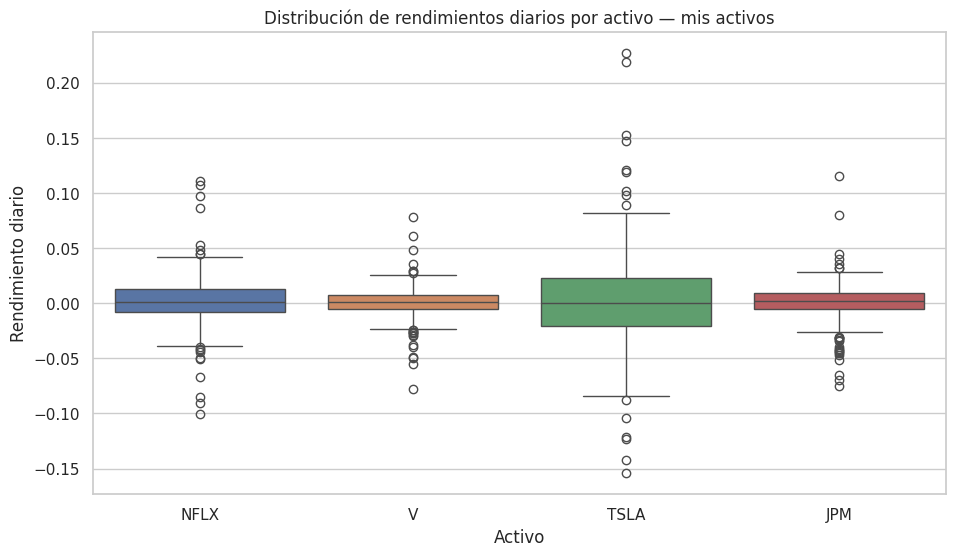

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(data=mi_rend, ax=ax)

ax.set_title("Distribución de rendimientos diarios por activo — mis activos")
ax.set_xlabel("Activo")
ax.set_ylabel("Rendimiento diario")

plt.show()

### Paso 8 — Matriz de correlación

Ticker,NFLX,V,TSLA,JPM
Ticker,,,,
NFLX,1.000,0.284,0.266,0.244
V,0.284,1.000,0.309,0.493
TSLA,0.266,0.309,1.000,0.369
JPM,0.244,0.493,0.369,1.000


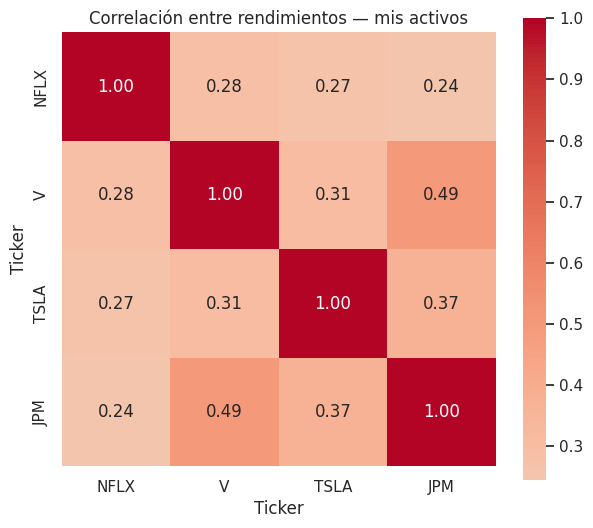

Par menos correlacionado: ('NFLX', 'JPM') 0.244
Par más correlacionado:   ('V', 'JPM') 0.493


In [39]:
mi_corr = mi_rend.corr()
display(mi_corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(mi_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)

ax.set_title("Correlación entre rendimientos — mis activos")

plt.show()

# Pares de activos, de menor a mayor correlación
mis_pares = pd.Series(
    {(a, b): mi_corr.loc[a, b] for a, b in combinations(mi_corr.columns, 2)}
).sort_values()
print("Par menos correlacionado:", mis_pares.index[0], round(mis_pares.iloc[0], 3))
print("Par más correlacionado:  ", mis_pares.index[-1], round(mis_pares.iloc[-1], 3))

### Paso 9 — Relación entre dos activos

Analizo el par **más correlacionado** de la matriz, para ver en las observaciones individuales lo que el coeficiente resume en un número.

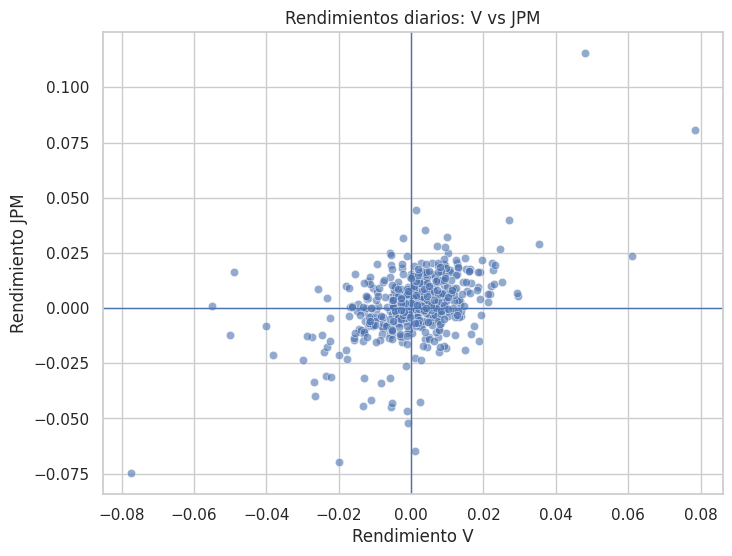

In [40]:
a, b = mis_pares.index[-1]

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=mi_rend, x=a, y=b, alpha=0.6, ax=ax)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_title(f"Rendimientos diarios: {a} vs {b}")
ax.set_xlabel(f"Rendimiento {a}")
ax.set_ylabel(f"Rendimiento {b}")

plt.show()

### Paso 10 — Conclusiones: 3 hallazgos

La celda siguiente redacta los hallazgos con **los números que salieron de mis datos**, con la estructura pedida: *Gráfico → Observación → Interpretación*.

In [41]:
# --- Cifras de apoyo ---
var_mi = mi_normalizado.iloc[-1] - 100                # variación acumulada (%)
mejor, peor = var_mi.idxmax(), var_mi.idxmin()

std_mi = mi_rend.std()
q1, q3 = mi_rend.quantile(0.25), mi_rend.quantile(0.75)
iqr = q3 - q1
fuera = ((mi_rend < q1 - 1.5 * iqr) | (mi_rend > q3 + 1.5 * iqr)).sum()   # observaciones fuera de los bigotes
mas_disp, menos_disp = std_mi.idxmax(), std_mi.idxmin()

brecha = var_mi.max() - var_mi.min()
if brecha >= 20:
    dif = "difiere de forma notable"
elif brecha >= 10:
    dif = "difiere de forma moderada"
else:
    dif = "es bastante parecido"

par_alto, r_alto = mis_pares.index[-1], mis_pares.iloc[-1]
par_bajo, r_bajo = mis_pares.index[0], mis_pares.iloc[0]

if r_alto >= 0.7:
    lectura = "alta: los dos activos se movieron de forma muy parecida, así que combinarlos reduce poco el riesgo"
elif r_alto >= 0.4:
    lectura = "moderada: comparten parte de su comportamiento, pero todavía aportan diversificación entre sí"
else:
    lectura = "baja: los activos se movieron de forma bastante independiente, lo que favorece la diversificación"

hallazgos = f"""
### Hallazgo 1 — Crecimiento relativo
- **Gráfico:** evolución normalizada (inicio = 100).
- **Observación:** {mejor} cerró el período en {mi_normalizado[mejor].iloc[-1]:.1f} ({var_mi[mejor]:+.1f} %) y {peor} en {mi_normalizado[peor].iloc[-1]:.1f} ({var_mi[peor]:+.1f} %).
- **Interpretación:** los cuatro activos partieron del mismo punto (100) y la distancia entre el mejor y el peor fue de {brecha:.1f} puntos, así que su rendimiento relativo en el período {dif}. Es una lectura histórica, no una recomendación de inversión.

### Hallazgo 2 — Dispersión de los rendimientos
- **Gráfico:** boxplot (y el histograma de {activo_hist}).
- **Observación:** {mas_disp} tuvo la mayor dispersión (desviación estándar diaria de {std_mi[mas_disp]*100:.2f} %, caja de {iqr[mas_disp]*100:.2f} puntos y {fuera[mas_disp]} observaciones fuera de los bigotes); {menos_disp} tuvo la menor ({std_mi[menos_disp]*100:.2f} %, caja de {iqr[menos_disp]*100:.2f} puntos y {fuera[menos_disp]} observaciones fuera de los bigotes).
- **Interpretación:** más dispersión significa cambios diarios más grandes, es decir, más volatilidad histórica y, en ese sentido, más riesgo. El boxplot no dice si esos movimientos fueron ganancias o pérdidas; para eso hay que mirar la evolución en el tiempo.

### Hallazgo 3 — Relación entre activos
- **Gráfico:** matriz de correlación y scatter plot de {par_alto[0]} vs {par_alto[1]}.
- **Observación:** las correlaciones entre pares van de {r_bajo:.2f} ({par_bajo[0]}–{par_bajo[1]}) a {r_alto:.2f} ({par_alto[0]}–{par_alto[1]}).
- **Interpretación:** el par más correlacionado ({par_alto[0]}–{par_alto[1]}) tiene una correlación {lectura}. Una correlación histórica no garantiza que se mantenga y no implica causalidad.
"""
display(Markdown(hallazgos))


### Hallazgo 1 — Crecimiento relativo
- **Gráfico:** evolución normalizada (inicio = 100).
- **Observación:** NFLX cerró el período en 200.1 (+100.1 %) y V en 137.5 (+37.5 %).
- **Interpretación:** los cuatro activos partieron del mismo punto (100) y la distancia entre el mejor y el peor fue de 62.6 puntos, así que su rendimiento relativo en el período difiere de forma notable. Es una lectura histórica, no una recomendación de inversión.

### Hallazgo 2 — Dispersión de los rendimientos
- **Gráfico:** boxplot (y el histograma de TSLA).
- **Observación:** TSLA tuvo la mayor dispersión (desviación estándar diaria de 4.00 %, caja de 4.33 puntos y 15 observaciones fuera de los bigotes); V tuvo la menor (1.25 %, caja de 1.25 puntos y 21 observaciones fuera de los bigotes).
- **Interpretación:** más dispersión significa cambios diarios más grandes, es decir, más volatilidad histórica y, en ese sentido, más riesgo. El boxplot no dice si esos movimientos fueron ganancias o pérdidas; para eso hay que mirar la evolución en el tiempo.

### Hallazgo 3 — Relación entre activos
- **Gráfico:** matriz de correlación y scatter plot de V vs JPM.
- **Observación:** las correlaciones entre pares van de 0.24 (NFLX–JPM) a 0.49 (V–JPM).
- **Interpretación:** el par más correlacionado (V–JPM) tiene una correlación moderada: comparten parte de su comportamiento, pero todavía aportan diversificación entre sí. Una correlación histórica no garantiza que se mantenga y no implica causalidad.



# 22. Reto final 🎯

Sin modificar el código inicialmente:

### Pregunta 1
¿Cuál activo presenta mayor dispersión de rendimientos?

### Pregunta 2
¿Cuáles dos activos presentan mayor correlación?

### Pregunta 3
¿Cuáles presentan menor correlación?

### Pregunta 4
¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?

### Pregunta 5
¿La evolución normalizada cuenta la misma historia que los precios originales?

### Pregunta 6
¿Qué información aporta el histograma que no aporta el gráfico temporal?

### Pregunta 7
¿Qué información aporta el scatter plot que no aporta el heatmap?

---

## ⭐ Regla de oro del EDA

Antes de hacer un gráfico pregunta:

> **¿Qué quiero saber?**

Después del gráfico pregunta:

> **¿Qué estoy observando?**

Y finalmente:

> **¿Qué puedo concluir razonablemente a partir de lo observado?**


---
## ✅ Respuestas al reto final

Las respuestas 1 a 5 se calculan con el código y las variables del análisis de ejemplo (`rendimientos`, `correlacion`, `cierre`, `cierre_normalizado`), sin modificarlo, como pide el enunciado. Las respuestas 6 y 7 son conceptuales.

In [42]:
# --- Pregunta 1: mayor dispersión de rendimientos ---
disp = rendimientos.std().sort_values(ascending=False)
print("Desviación estándar diaria de los rendimientos (%):")
print((disp * 100).round(2))

# --- Preguntas 2 y 3: mayor y menor correlación ---
pares_base = pd.Series(
    {(a, b): correlacion.loc[a, b] for a, b in combinations(correlacion.columns, 2)}
).sort_values()
print("\nCorrelación entre pares, de menor a mayor:")
print(pares_base.round(3))

respuesta_1_3 = f"""
**Respuesta 1.** {disp.index[0]} presenta la mayor dispersión de rendimientos (desviación estándar diaria de {disp.iloc[0]*100:.2f} %); {disp.index[-1]} presenta la menor ({disp.iloc[-1]*100:.2f} %).

**Respuesta 2.** Los activos con mayor correlación son {pares_base.index[-1][0]} y {pares_base.index[-1][1]} ({pares_base.iloc[-1]:.2f}).

**Respuesta 3.** Los activos con menor correlación son {pares_base.index[0][0]} y {pares_base.index[0][1]} ({pares_base.iloc[0]:.2f}).
"""
display(Markdown(respuesta_1_3))

Desviación estándar diaria de los rendimientos (%):
Ticker
NVDA     3.22
AMZN     1.98
GOOGL    1.91
AAPL     1.76
MSFT     1.40
dtype: float64

Correlación entre pares, de menor a mayor:
AAPL   NVDA     0.351
GOOGL  NVDA     0.399
AAPL   GOOGL    0.443
       MSFT     0.479
       AMZN     0.484
GOOGL  MSFT     0.486
AMZN   NVDA     0.505
       GOOGL    0.540
MSFT   NVDA     0.549
AMZN   MSFT     0.626
dtype: float64



**Respuesta 1.** NVDA presenta la mayor dispersión de rendimientos (desviación estándar diaria de 3.22 %); MSFT presenta la menor (1.40 %).

**Respuesta 2.** Los activos con mayor correlación son AMZN y MSFT (0.63).

**Respuesta 3.** Los activos con menor correlación son AAPL y NVDA (0.35).


In [43]:
# --- Pregunta 4: ¿hay días con movimientos extremos simultáneos? ---
# Criterio: un movimiento es "extremo" si su valor absoluto está en el 5 % más grande de ese activo.
umbral = rendimientos.abs().quantile(0.95)
extremos = rendimientos.abs() >= umbral
n_ext = extremos.sum(axis=1)                 # cuántos activos tuvieron un movimiento extremo ese día
max_ext = int(n_ext.max())
dias_3 = n_ext[n_ext >= 3]
fechas_max = n_ext[n_ext == max_ext].index

print(f"Días con 3 o más activos en movimiento extremo a la vez: {len(dias_3)} de {len(n_ext)}")
print(f"Máximo de activos extremos en un mismo día: {max_ext} (ocurrió en {len(fechas_max)} día(s))")
print("\nRendimientos (%) en los días con más activos extremos a la vez:")
display((rendimientos.loc[fechas_max[:5]] * 100).round(2))

primera = fechas_max[0]
activos_ext = list(extremos.columns[extremos.loc[primera]])
mismo_signo = rendimientos.loc[primera, activos_ext].gt(0).all() or rendimientos.loc[primera, activos_ext].lt(0).all()
signo_txt = "todos con el mismo signo" if mismo_signo else "con signos distintos"

if len(dias_3) > 0:
    resp4 = (f"**Respuesta 4.** Sí. Hubo {len(dias_3)} días con 3 o más activos en movimiento extremo a la vez; "
             f"el máximo fue de {max_ext} activos el {primera.date()} ({', '.join(activos_ext)}, {signo_txt}).")
else:
    resp4 = (f"**Respuesta 4.** No hubo días con 3 o más activos en movimiento extremo a la vez; "
             f"el máximo fue de {max_ext} activo(s) el {primera.date()} ({', '.join(activos_ext)}).")
display(Markdown(resp4))

Días con 3 o más activos en movimiento extremo a la vez: 11 de 501
Máximo de activos extremos en un mismo día: 5 (ocurrió en 1 día(s))

Rendimientos (%) en los días con más activos extremos a la vez:


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2025-04-09,15.33,11.98,9.68,10.13,18.72


**Respuesta 4.** Sí. Hubo 11 días con 3 o más activos en movimiento extremo a la vez; el máximo fue de 5 activos el 2025-04-09 (AAPL, AMZN, GOOGL, MSFT, NVDA, todos con el mismo signo).

In [44]:
# --- Pregunta 5: ¿la evolución normalizada cuenta la misma historia que los precios? ---
rank_precio = cierre.iloc[-1].sort_values(ascending=False)
rank_norm = (cierre_normalizado.iloc[-1] - 100).sort_values(ascending=False)

print("Precio final (USD), de mayor a menor:")
print(rank_precio.round(2))
print("\nVariación acumulada normalizada (%), de mayor a menor:")
print(rank_norm.round(1))

if list(rank_precio.index) == list(rank_norm.index):
    apertura = "Solo en parte."
    parte_datos = (f"En estos datos el orden final por precio coincide con el orden por crecimiento relativo ({' > '.join(rank_norm.index)}), "
                   "pero eso no hace equivalentes los gráficos: el de precios no permite saber cuánto creció cada uno ni comparar trayectorias.")
else:
    apertura = "No."
    parte_datos = (f"En estos datos el orden por precio final ({' > '.join(rank_precio.index)}) no coincide con el orden por "
                   f"crecimiento relativo ({' > '.join(rank_norm.index)}).")

display(Markdown(f"""
**Respuesta 5.** {apertura} El gráfico de precios muestra **niveles nominales**: el activo con precio más alto se ve más arriba aunque no haya crecido más. La normalización muestra **cuánto cambió cada activo respecto a su propio inicio**, que es lo que permite compararlos. {parte_datos}
"""))

Precio final (USD), de mayor a menor:
Ticker
MSFT     480.57
GOOGL    312.39
AAPL     271.12
AMZN     230.82
NVDA     186.06
Name: 2025-12-31 00:00:00, dtype: float64

Variación acumulada normalizada (%), de mayor a menor:
Ticker
NVDA     287.4
GOOGL    128.2
AMZN      54.0
AAPL      47.8
MSFT      32.3
Name: 2025-12-31 00:00:00, dtype: float64



**Respuesta 5.** No. El gráfico de precios muestra **niveles nominales**: el activo con precio más alto se ve más arriba aunque no haya crecido más. La normalización muestra **cuánto cambió cada activo respecto a su propio inicio**, que es lo que permite compararlos. En estos datos el orden por precio final (MSFT > GOOGL > AAPL > AMZN > NVDA) no coincide con el orden por crecimiento relativo (NVDA > GOOGL > AMZN > AAPL > MSFT).


**Respuesta 6 — ¿Qué aporta el histograma que no aporta el gráfico temporal?** El gráfico temporal muestra *cuándo* ocurrió cada rendimiento y permite ver períodos de mayor variabilidad. El histograma ignora el orden en el tiempo y muestra *cómo se distribuyen* los valores: dónde se concentran (centro), qué tan extendidos están (dispersión), qué tan frecuentes son los valores extremos (colas) y si la forma es simétrica o sesgada. Es la forma de ver la frecuencia con que ocurre cada rango de rendimiento, algo difícil de leer en una línea con cientos de puntos.

**Respuesta 7 — ¿Qué aporta el scatter plot que no aporta el heatmap?** El heatmap resume cada par de activos en **un solo número** (el coeficiente de correlación lineal). El scatter plot muestra **las observaciones individuales**: permite ver si la relación es realmente lineal, si hay valores extremos o días atípicos que están moviendo el coeficiente, si hay grupos de puntos y qué pasa cuando uno de los activos cae. Dos pares con la misma correlación pueden tener nubes de puntos muy distintas, y eso solo se ve en el scatter.